# **Human Facial Expression Recognition Using Deep Learning and Computer Vision Techniques**

In [2]:
import os
import cv2
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from collections import Counter

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    log_loss
)

# TensorFlow / Keras
import tensorflow as tf

from tensorflow.keras.models import Model, Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Input,
    Average
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.optimizers import Adam

# EfficientNet (B0 & B2)
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

# ResNet
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# DenseNet
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess


# SETTINGS
warnings.filterwarnings('ignore')

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Data Loading

In [3]:
# DATA LOADING

BASE = "/kaggle/input/datasets/aryan0910/face-emotion-dataset-emotionx-09/Face Emotion Dataset (EMOTIONX-09) v2/Face Emotion Dataset (EMOTIONX-09) v2"

def load_dataset(path):
    
    images = []
    labels = []

    classes = sorted(os.listdir(path))

    for label, emotion in enumerate(classes):

        emotion_folder = os.path.join(path, emotion)

        for image_name in os.listdir(emotion_folder):

            image_path = os.path.join(emotion_folder, image_name)

            img = cv2.imread(image_path)

            if img is not None:

                img = cv2.resize(img, (96, 96))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                images.append(img)
                labels.append(label)

    return np.array(images), np.array(labels), classes

In [4]:
# Set dataset directories for training and testing
TRAIN_DIR = os.path.join(BASE, "train")
TEST_DIR  = os.path.join(BASE, "test")

print("Train path:", TRAIN_DIR)  # train path
print("Test path:", TEST_DIR)    # test path

Train path: /kaggle/input/datasets/aryan0910/face-emotion-dataset-emotionx-09/Face Emotion Dataset (EMOTIONX-09) v2/Face Emotion Dataset (EMOTIONX-09) v2/train
Test path: /kaggle/input/datasets/aryan0910/face-emotion-dataset-emotionx-09/Face Emotion Dataset (EMOTIONX-09) v2/Face Emotion Dataset (EMOTIONX-09) v2/test


In [5]:
# Load Train and Test Dataset

X_train_raw, y_train, CLASS_NAMES = load_dataset(TRAIN_DIR)
X_test_raw, y_test, _ = load_dataset(TEST_DIR)


# Dataset Summary

print("~" * 50)
print("        FACE EMOTION DATASET SUMMARY")
print("~" * 50)

print(f"Training Images   : {X_train_raw.shape}")
print(f"Testing Images    : {X_test_raw.shape}")

print("-" * 50)

print(f"Number of Classes : {len(CLASS_NAMES)}")
print(f"Class Names       : {CLASS_NAMES}")

print("-" * 50)

print(f"Image Data Type   : {X_train_raw.dtype}")
print(f"Pixel Value Range : {X_train_raw.min()} to {X_train_raw.max()}")

print("~" * 50)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        FACE EMOTION DATASET SUMMARY
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Training Images   : (3887, 96, 96, 3)
Testing Images    : (976, 96, 96, 3)
--------------------------------------------------
Number of Classes : 9
Class Names       : ['Angry', 'Anxiety', 'Confusion', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Suprise']
--------------------------------------------------
Image Data Type   : uint8
Pixel Value Range : 0 to 255
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


## EDA

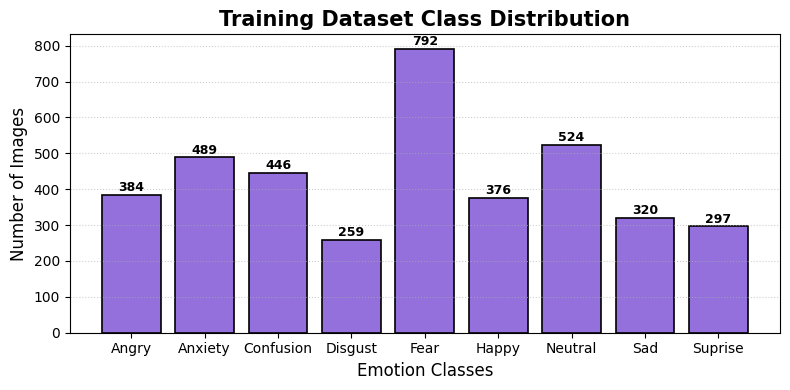

In [15]:
# Class Distribution of Training Data

plt.figure(figsize=(8,4))

# Count samples in each class
class_counts = Counter(y_train)

# Labels and values
emotion_labels = [CLASS_NAMES[i] for i in sorted(class_counts.keys())]
emotion_counts = [class_counts[i] for i in sorted(class_counts.keys())]

# Create bar plot
bars = plt.bar(
    emotion_labels,
    emotion_counts,
    color="mediumpurple",
    edgecolor="black",
    linewidth=1.2
)

# Title and labels
plt.title(
    "Training Dataset Class Distribution",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Emotion Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

# Add soft grid style
plt.grid(
    axis='y',
    linestyle=':',
    alpha=0.6
)

# Add value labels on bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10,
        f"{height}",
        ha='center',
        fontsize=9,
        fontweight='bold'
    )


plt.tight_layout()
plt.show()

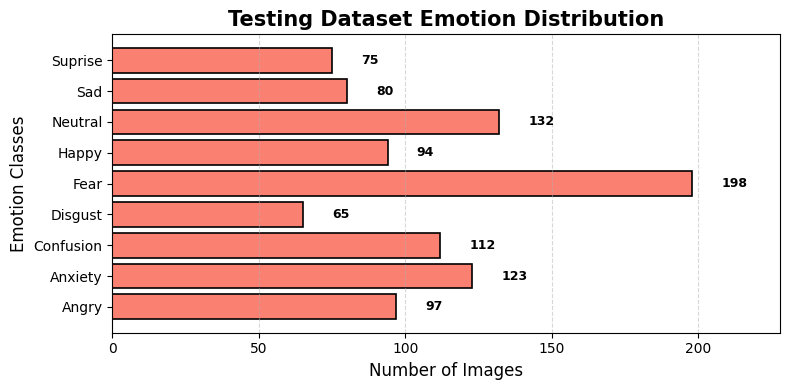

In [31]:
# Horizontal Class Distribution Plot for Testing Data

plt.figure(figsize=(8, 4))

# Count class samples
test_class_counts = Counter(y_test)

# Labels and values
test_labels = [CLASS_NAMES[i] for i in sorted(test_class_counts.keys())]
test_counts = [test_class_counts[i] for i in sorted(test_class_counts.keys())]

# Create horizontal bar chart
bars = plt.barh(
    test_labels,
    test_counts,
    color="salmon",
    edgecolor="black",
    linewidth=1.2
)

# Increase x-axis limit
plt.xlim(0, max(test_counts) + 30)

# Title and labels
plt.title(
    "Testing Dataset Emotion Distribution",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Number of Images", fontsize=12)
plt.ylabel("Emotion Classes", fontsize=12)

# Add grid
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

# Add values beside bars
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 10,
        bar.get_y() + bar.get_height()/2,
        f"{width}",
        va='center',
        fontsize=9,
        fontweight='bold'
    )


plt.tight_layout()
plt.show()

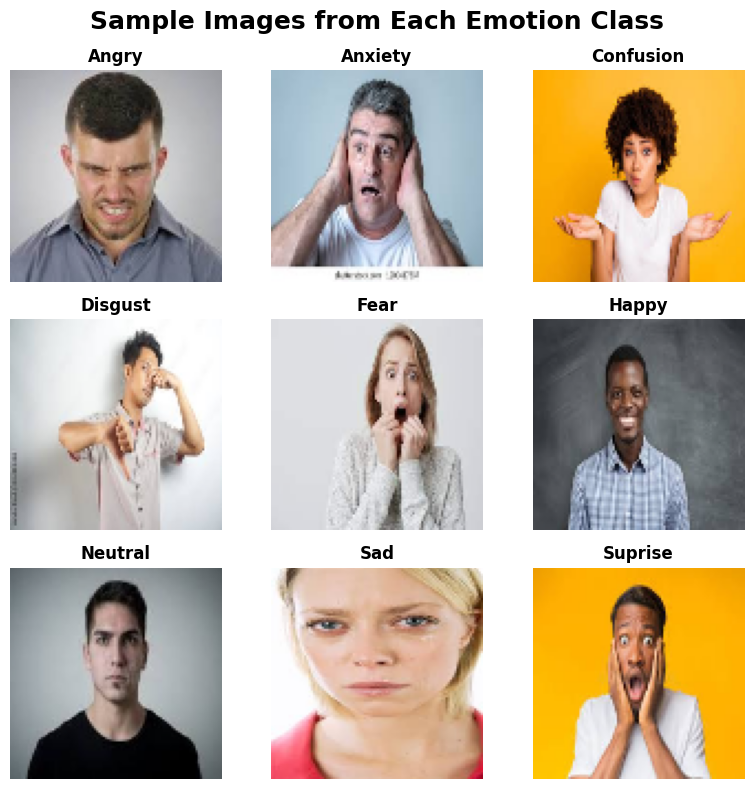

In [32]:
# Display One Sample Image Per Class (3x3 Grid)

num_classes = len(CLASS_NAMES)

# Create 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

# Flatten axes for easy looping
axes = axes.flatten()

# Display one sample image from each class
for i in range(num_classes):

    # Get one sample 
    idx = np.where(y_train == i)[0][-1]

    # Show image
    axes[i].imshow(X_train_raw[idx])

    # Set title
    axes[i].set_title(
        CLASS_NAMES[i],
        fontsize=12,
        fontweight='bold'
    )

    # Remove axis
    axes[i].axis('off')

# Hide unused subplots
for j in range(num_classes, len(axes)):
    axes[j].axis('off')

# Main title
plt.suptitle(
    "Sample Images from Each Emotion Class",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

##  Preprocessing

In [6]:
# IMAGE PREPROCESSING FUNCTIONS

NUM_CLASSES = len(CLASS_NAMES)


# 1. CLAHE Enhancement
def apply_clahe_uint8(img_uint8):
    """
    Apply CLAHE on RGB image
    Input  : uint8 RGB image
    Output : uint8 RGB image
    """

    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    enhanced_lab = cv2.merge([l, a, b])

    enhanced_img = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2RGB
    )

    return enhanced_img


# 2. Gaussian Blur (Noise Reduction)
def apply_gaussian_blur(img_uint8):
    """
    Reduce image noise using Gaussian Blur
    """

    blurred_img = cv2.GaussianBlur(
        img_uint8,
        (3, 3),
        0
    )

    return blurred_img


# 3. Sharpening Filter
def apply_sharpening(img_uint8):
    """
    Enhance edges and facial features
    """

    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])

    sharpened_img = cv2.filter2D(
        img_uint8,
        -1,
        kernel
    )

    return sharpened_img

In [7]:
# APPLY ALL PREPROCESSING TECHNIQUES

print("~" * 60)
print("        APPLYING IMAGE PREPROCESSING")
print("~" * 60)

# Training Set Preprocessing

print("\nProcessing Training Images...")

X_train_processed = []

for img in X_train_raw:

    # Noise Reduction
    img = apply_gaussian_blur(img)

    # CLAHE Enhancement
    img = apply_clahe_uint8(img)

    # Sharpening
    img = apply_sharpening(img)

    X_train_processed.append(img)

X_train_processed = np.array(X_train_processed)


# Testing Set Preprocessing

print("Processing Testing Images...")

X_test_processed = []

for img in X_test_raw:
    
    # Noise Reduction
    img = apply_gaussian_blur(img)

    # CLAHE Enhancement
    img = apply_clahe_uint8(img)

    # Sharpening
    img = apply_sharpening(img)

    X_test_processed.append(img)

X_test_processed = np.array(X_test_processed)


# Normalize Images

print("\nNormalizing Pixel Values...")

X_train_norm = X_train_raw.astype("float32") / 255.0

X_train = X_train_processed.astype("float32") / 255.0
X_test = X_test_processed.astype("float32") / 255.0


# One-Hot Encode Labels

print("Encoding Labels...")

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)


# Data Augmentation

print("Initializing Data Augmentation...")

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True
)

datagen.fit(X_train)


#  Final Summary

print("\n" + "~" * 60)
print("        PREPROCESSING COMPLETED")
print("~" * 60)

print(f"Processed Training Shape : {X_train.shape}")
print(f"Processed Testing Shape  : {X_test.shape}")

print(f"\nPixel Value Range        : "
      f"{X_train.min():.2f} to {X_train.max():.2f}")

print(f"\nNumber of Classes        : {NUM_CLASSES}")

print("~" * 60)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        APPLYING IMAGE PREPROCESSING
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Processing Training Images...
Processing Testing Images...

Normalizing Pixel Values...
Encoding Labels...
Initializing Data Augmentation...

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        PREPROCESSING COMPLETED
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Processed Training Shape : (3887, 96, 96, 3)
Processed Testing Shape  : (976, 96, 96, 3)

Pixel Value Range        : 0.00 to 1.00

Number of Classes        : 9
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


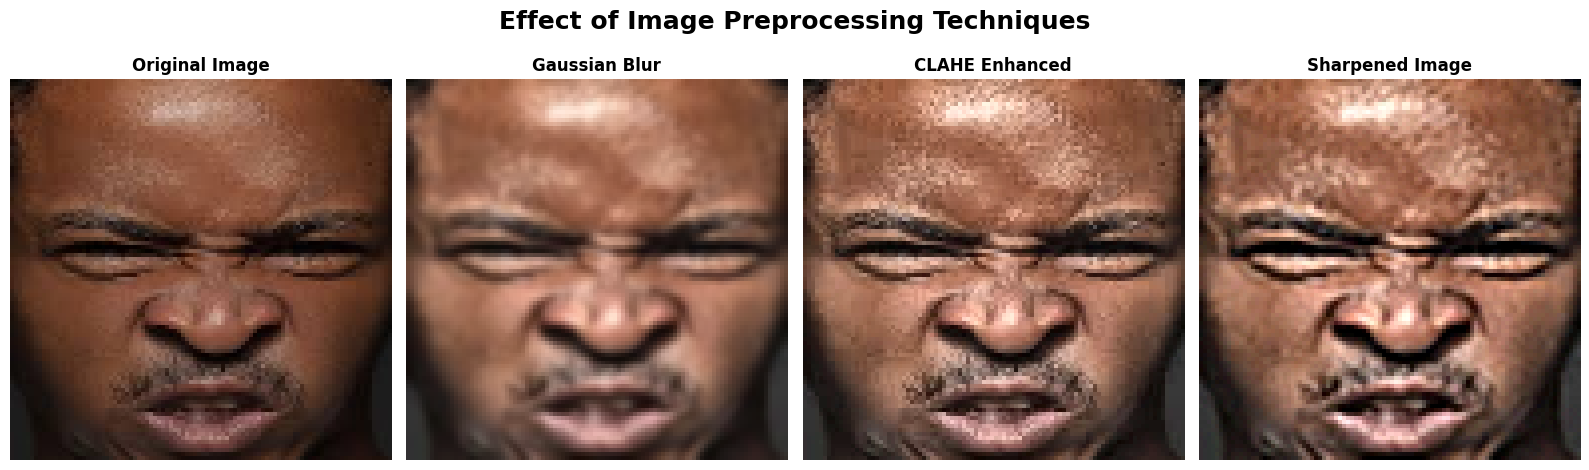

In [8]:
# Compare Original vs Preprocessing Techniques

sample_index = 10

# Original Image
original_img = X_train_raw[sample_index]

# Apply preprocessing methods
clahe_img = apply_clahe_uint8(original_img)

blur_img = apply_gaussian_blur(clahe_img)

sharp_img = apply_sharpening(blur_img)

# Plot Images
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# Original
axes[0].imshow(original_img)
axes[0].set_title(
    "Original Image",
    fontsize=12,
    fontweight='bold'
)
axes[0].axis('off')


# Gaussian Blur
axes[1].imshow(blur_img)
axes[1].set_title(
    "Gaussian Blur",
    fontsize=12,
    fontweight='bold'
)
axes[1].axis('off')

# CLAHE
axes[2].imshow(clahe_img)
axes[2].set_title(
    "CLAHE Enhanced",
    fontsize=12,
    fontweight='bold'
)
axes[2].axis('off')

# Sharpened
axes[3].imshow(sharp_img)
axes[3].set_title(
    "Sharpened Image",
    fontsize=12,
    fontweight='bold'
)
axes[3].axis('off')

# Main title
plt.suptitle(
    "Effect of Image Preprocessing Techniques",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [19]:
#  COMPUTE CLASS WEIGHTS

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary
class_weights = dict(enumerate(class_weights))


# Display Class Weights
print("~" * 45)
print("         CLASS WEIGHT SUMMARY")
print("~" * 45)

for class_id, weight in class_weights.items():

    print(f"{CLASS_NAMES[class_id]:<15} : {weight:.4f}")

print("~" * 45)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
         CLASS WEIGHT SUMMARY
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Angry           : 1.1247
Anxiety         : 0.8832
Confusion       : 0.9684
Disgust         : 1.6675
Fear            : 0.5453
Happy           : 1.1486
Neutral         : 0.8242
Sad             : 1.3497
Suprise         : 1.4542
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


## ResNet50 Model

In [20]:
# LOAD PRETRAINED RESNET50 BASE MODEL

# Load ResNet50 Model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

# Freeze pretrained layers
base_model.trainable = False


# Model Summary
print("~" * 55)
print("        RESNET50 BASE MODEL LOADED")
print("~" * 55)

print(f"Input Shape        : (96, 96, 3)")
print(f"Pretrained Weights : ImageNet")
print(f"Top Layers Removed : Yes")
print(f"Trainable          : {base_model.trainable}")

print("~" * 55)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        RESNET50 BASE MODEL LOADED
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Input Shape        : (96, 96, 3)
Pretrained Weights : ImageNet
Top Layers Removed : Yes
Trainable          : False
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [21]:
# ADD CUSTOM CLASSIFICATION HEAD

# Extract features from base model
x = base_model.output

# Global Average Pooling
x = GlobalAveragePooling2D()(x)

# Fully Connected Layer
x = Dense(
    256,
    activation='relu'
)(x)

# Dropout Regularization
x = Dropout(0.4)(x)

# Output Layer
output = Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)


print("~" * 55)
print("       CUSTOM CLASSIFICATION HEAD ADDED")
print("~" * 55)

print("GlobalAveragePooling2D  → Added")
print("Dense Layer (256)       → Added")
print("Dropout Layer (0.4)     → Added")
print(f"Output Layer            → {NUM_CLASSES} Classes")

print("~" * 55)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
       CUSTOM CLASSIFICATION HEAD ADDED
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
GlobalAveragePooling2D  → Added
Dense Layer (256)       → Added
Dropout Layer (0.4)     → Added
Output Layer            → 9 Classes
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [22]:
# BUILD MODEL

model1 = Model(inputs=base_model.input, outputs=output, name="ResNet50")

In [23]:
# COMPILE RESNET50 MODEL

model1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("~" * 55)
print("           MODEL COMPILATION SUCCESSFUL")
print("~" * 55)

print("Optimizer        : Adam")
print("Learning Rate    : 0.001")
print("Loss Function    : Categorical Crossentropy")
print("Evaluation Metric: Accuracy")

print("~" * 55)

# Display Model Architecture
model1.summary()

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
           MODEL COMPILATION SUCCESSFUL
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Optimizer        : Adam
Learning Rate    : 0.001
Loss Function    : Categorical Crossentropy
Evaluation Metric: Accuracy
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 102, 102,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 48, 48,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 48, 48,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 48, 48,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 50, 50,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 24, 24,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 24, 24,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 24, 24,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 24, 24,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 24, 24,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 24, 24,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 24, 24,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 24, 24,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 24, 24,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 24, 24,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 24, 24,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,569 (91.99 MB)

 Trainable params: 526,857 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [25]:
# DEFINE CALLBACKS

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Combine Callbacks
callbacks = [
    early_stopping,
    reduce_lr
]


print("~" * 55)
print("            CALLBACKS INITIALIZED")
print("~" * 55)

print("EarlyStopping      → Enabled")
print("ReduceLROnPlateau  → Enabled")

print("~" * 55)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            CALLBACKS INITIALIZED
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EarlyStopping      → Enabled
ReduceLROnPlateau  → Enabled
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [26]:
# TRAIN RESNET50 MODEL

print("~" * 55)
print("             TRAINING STARTED")
print("~" * 55)

history1 = model1.fit(
    datagen.flow(
        X_train,
        y_train_cat,
        batch_size=32
    ),
    validation_data=(
        X_test,
        y_test_cat
    ),

    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

print("\n" + "~" * 55)
print("          TRAINING COMPLETED")
print("~" * 55)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
             TRAINING STARTED
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Epoch 1/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 33s 176ms/step - accuracy: 0.1297 - loss: 2.2180 - val_accuracy: 0.2561 - val_loss: 2.1140 - learning_rate: 0.0010
Epoch 2/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.2079 - loss: 2.1282 - val_accuracy: 0.2828 - val_loss: 2.0472 - learning_rate: 0.0010
Epoch 3/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.2194 - loss: 2.0859 - val_accuracy: 0.2797 - val_loss: 1.9966 - learning_rate: 0.0010
Epoch 4/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.2475 - loss: 2.0483 - val_accuracy: 0.3023 - val_loss: 1.9253 - learning_rate: 0.0010
Epoch 5/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.2627 - loss: 2.0171 - val_accuracy: 0.3043 - val_loss: 1.8928 - learning_rate: 0.0010
Epoch 6/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.2742 - loss: 1.9950

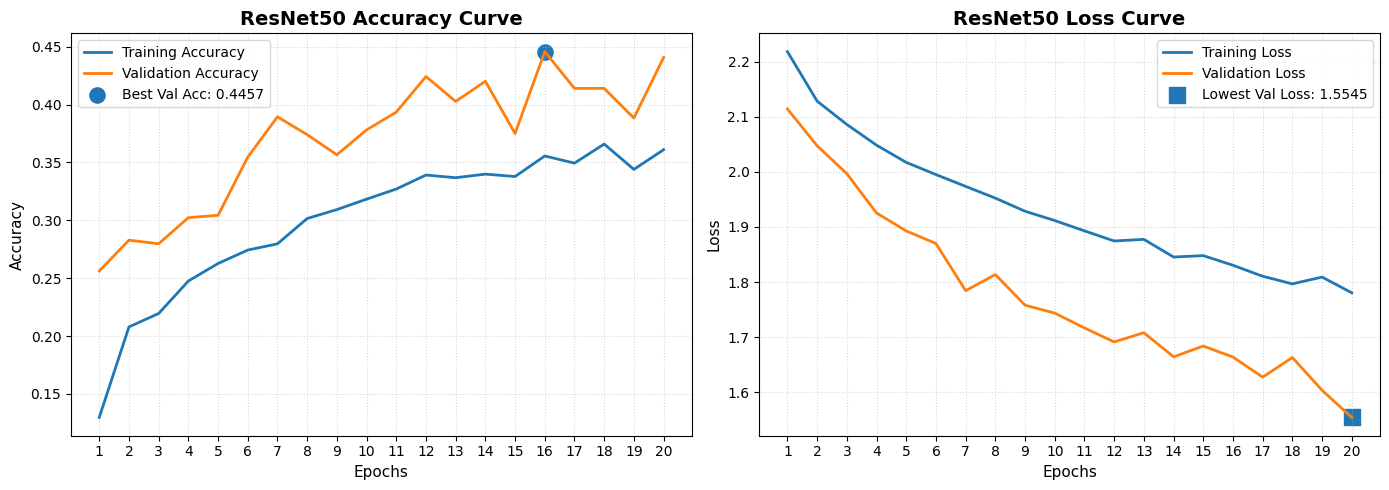

In [27]:
#  TRAINING PERFORMANCE CURVES

plt.figure(figsize=(14, 5))

# Accuracy Curve

plt.subplot(1, 2, 1)

train_acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

# Plot curves
plt.plot(
    epochs,
    train_acc,
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    epochs,
    val_acc,
    linewidth=2,
    label='Validation Accuracy'
)

# Mark best validation accuracy
best_acc_epoch = np.argmax(val_acc) + 1
best_acc = max(val_acc)

plt.scatter(
    best_acc_epoch,
    best_acc,
    s=120,
    label=f'Best Val Acc: {best_acc:.4f}'
)

# Labels and title
plt.title(
    "ResNet50 Accuracy Curve",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Epochs", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)

plt.xticks(epochs)

plt.grid(
    linestyle=':',
    alpha=0.5
)

plt.legend()


# Loss Curve

plt.subplot(1, 2, 2)

train_loss = history1.history['loss']
val_loss = history1.history['val_loss']

# Plot curves
plt.plot(
    epochs,
    train_loss,
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    epochs,
    val_loss,
    linewidth=2,
    label='Validation Loss'
)

# Mark lowest validation loss
best_loss_epoch = np.argmin(val_loss) + 1
best_loss = min(val_loss)

plt.scatter(
    best_loss_epoch,
    best_loss,
    s=120,
    marker='s',
    label=f'Lowest Val Loss: {best_loss:.4f}'
)

# Labels and title
plt.title(
    "ResNet50 Loss Curve",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Epochs", fontsize=11)
plt.ylabel("Loss", fontsize=11)

plt.xticks(epochs)

plt.grid(
    linestyle=':',
    alpha=0.5
)

plt.legend()

plt.tight_layout()
plt.show()

### Fine-Tuning

In [28]:

# FINE-TUNING RESNET50 MODEL

print("~" * 60)
print("           STARTING FINE-TUNING")
print("~" * 60)

# Unfreeze Base Model
base_model.trainable = True

# Freeze Initial Layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("\nLast 30 layers unfrozen for fine-tuning.")

# Recompile Model with Lower Learning Rate
model1.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled with lower learning rate.")


# Fine-Tuning Training

history_fine = model1.fit(

    datagen.flow(
        X_train,
        y_train_cat,
        batch_size=32
    ),

    validation_data=(
        X_test,
        y_test_cat
    ),

    epochs=40,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

print("\n" + "~" * 60)
print("           FINE-TUNING COMPLETED")
print("~" * 60)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
           STARTING FINE-TUNING
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Last 30 layers unfrozen for fine-tuning.
Model recompiled with lower learning rate.
Epoch 1/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 47s 214ms/step - accuracy: 0.3110 - loss: 2.6786 - val_accuracy: 0.4098 - val_loss: 1.6358 - learning_rate: 1.0000e-04
Epoch 2/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.3905 - loss: 1.7178 - val_accuracy: 0.5082 - val_loss: 1.4115 - learning_rate: 1.0000e-04
Epoch 3/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.3805 - loss: 1.6725 - val_accuracy: 0.5564 - val_loss: 1.2779 - learning_rate: 1.0000e-04
Epoch 4/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.4307 - loss: 1.5576 - val_accuracy: 0.5400 - val_loss: 1.2854 - learning_rate: 1.0000e-04
Epoch 5/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.4561 - loss: 1.5097 - val_accuracy: 0.5830 - val_loss: 1.158

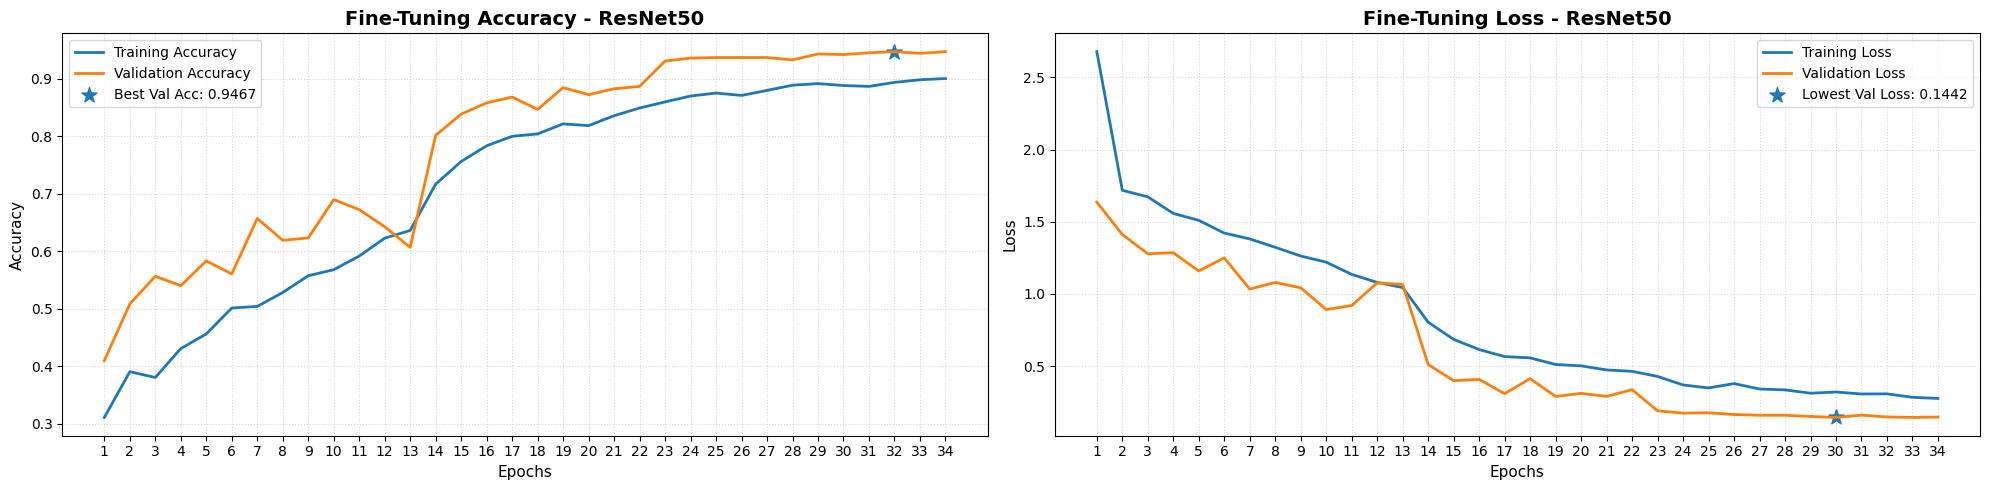

In [29]:
# FINE-TUNING PERFORMANCE CURVES

plt.figure(figsize=(20, 5))

# Fine-Tuning Accuracy Curve

plt.subplot(1, 2, 1)

fine_train_acc = history_fine.history['accuracy']
fine_val_acc = history_fine.history['val_accuracy']

fine_epochs = range(1, len(fine_train_acc) + 1)

# Plot accuracy curves
plt.plot(
    fine_epochs,
    fine_train_acc,
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    fine_epochs,
    fine_val_acc,
    linewidth=2,
    label='Validation Accuracy'
)

# Best validation accuracy point
best_fine_acc_epoch = np.argmax(fine_val_acc) + 1
best_fine_acc = max(fine_val_acc)

plt.scatter(
    best_fine_acc_epoch,
    best_fine_acc,
    s=130,
    marker='*',
    label=f'Best Val Acc: {best_fine_acc:.4f}'
)

# Labels and styling
plt.title(
    "Fine-Tuning Accuracy - ResNet50",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Epochs", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)

plt.xticks(fine_epochs)

plt.grid(
    linestyle=':',
    alpha=0.5
)

plt.legend()


# Fine-Tuning Loss Curve

plt.subplot(1, 2, 2)

fine_train_loss = history_fine.history['loss']
fine_val_loss = history_fine.history['val_loss']

# Plot loss curves
plt.plot(
    fine_epochs,
    fine_train_loss,
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    fine_epochs,
    fine_val_loss,
    linewidth=2,
    label='Validation Loss'
)

# Lowest validation loss point
best_fine_loss_epoch = np.argmin(fine_val_loss) + 1
best_fine_loss = min(fine_val_loss)

plt.scatter(
    best_fine_loss_epoch,
    best_fine_loss,
    s=130,
    marker='*',
    label=f'Lowest Val Loss: {best_fine_loss:.4f}'
)

# Labels and styling
plt.title(
    "Fine-Tuning Loss - ResNet50",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Epochs", fontsize=11)
plt.ylabel("Loss", fontsize=11)

plt.xticks(fine_epochs)

plt.grid(
    linestyle=':',
    alpha=0.5
)

plt.legend()

plt.tight_layout()
plt.show()

In [30]:
# PREDICTIONS

y_pred_probs = model1.predict(X_test)

# Convert to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step


In [31]:
# EVALUATION METRICS - RESNET50 MODEL

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1_score_value = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

logloss = log_loss(
    y_test,
    y_pred_probs
)


# Display Results
print("~" * 55)
print("        RESNET50 MODEL PERFORMANCE")
print("~" * 55)

print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1-Score   : {f1_score_value:.4f}")
print(f"Log Loss   : {logloss:.4f}")

print("~" * 55)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        RESNET50 MODEL PERFORMANCE
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Accuracy   : 0.9416
Precision  : 0.9434
Recall     : 0.9416
F1-Score   : 0.9412
Log Loss   : 0.1442
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [44]:
# Save the fine-tuned ResNet50 model
model1.save("resnet50_finetuned.keras")

In [33]:
# CLASSIFICATION REPORT

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

       Angry       0.96      1.00      0.98        97
     Anxiety       0.93      0.82      0.87       123
   Confusion       0.89      1.00      0.94       112
     Disgust       0.96      0.98      0.97        65
        Fear       0.90      0.93      0.92       198
       Happy       1.00      0.97      0.98        94
     Neutral       0.99      0.95      0.97       132
         Sad       0.92      0.99      0.95        80
     Suprise       1.00      0.88      0.94        75

    accuracy                           0.94       976
   macro avg       0.95      0.95      0.95       976
weighted avg       0.94      0.94      0.94       976



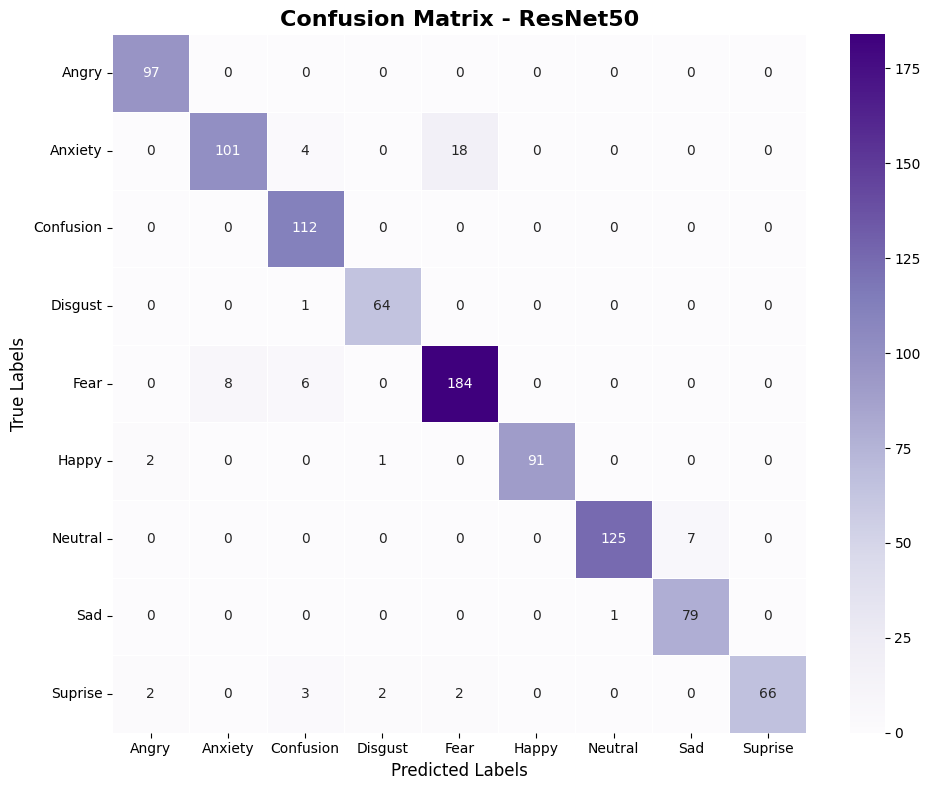

In [34]:
#  CONFUSION MATRIX - RESNET50 MODEL

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    linecolor='white'
)

# Titles and Labels
plt.title(
    "Confusion Matrix - ResNet50",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    "Predicted Labels",
    fontsize=12
)

plt.ylabel(
    "True Labels",
    fontsize=12
)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

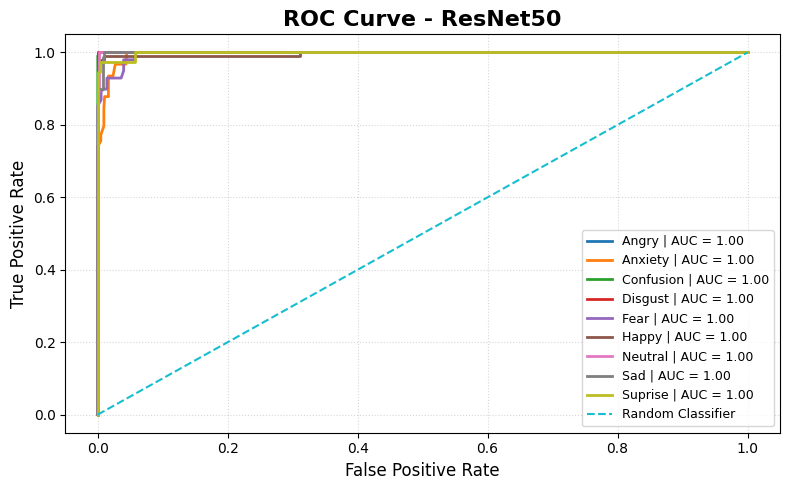

In [35]:
# ROC CURVE - RESNET50 MODEL

# Convert Labels to Binary Format
y_test_bin = label_binarize(
    y_test,
    classes=range(NUM_CLASSES)
)

# Plot ROC Curves
plt.figure(figsize=(8, 5))

for i in range(NUM_CLASSES):

    # Compute ROC values
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_probs[:, i]
    )

    # Compute AUC Score
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{CLASS_NAMES[i]} | AUC = {roc_auc:.2f}"
    )

# Random Guess Line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.5,
    label='Random Classifier'
)

# Titles and Labels
plt.title(
    "ROC Curve - ResNet50",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

# Grid
plt.grid(
    linestyle=':',
    alpha=0.5
)

# Legend
plt.legend(
    fontsize=9,
    loc='lower right'
)

plt.tight_layout()
plt.show()

## MODEL 2 — DenseNet121

In [45]:
# LOAD PRETRAINED DenseNet121 BASE MODEL
# DenseNet121 uses dense connections between layers which improves
# feature reuse and gradient flow, often achieving excellent accuracy
# on small/medium datasets.

base_model3 = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

# Freeze pretrained layers
base_model3.trainable = False

print("~" * 60)
print("        DenseNet121 BASE MODEL LOADED")
print("~" * 60)
print(f"Input Shape        : (96, 96, 3)")
print(f"Pretrained Weights : ImageNet")
print(f"Top Layers Removed : Yes")
print(f"Trainable          : {base_model3.trainable}")
print("~" * 60)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        DenseNet121 BASE MODEL LOADED
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Input Shape        : (96, 96, 3)
Pretrained Weights : ImageNet
Top Layers Removed : Yes
Trainable          : False
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [46]:
# ADD CUSTOM CLASSIFICATION HEAD — DenseNet121

x3 = base_model3.output

# Global Average Pooling
x3 = GlobalAveragePooling2D()(x3)

# Fully Connected + Batch Norm + Dropout
x3 = Dense(512, activation='relu')(x3)
x3 = BatchNormalization()(x3)
x3 = Dropout(0.4)(x3)

x3 = Dense(256, activation='relu')(x3)
x3 = BatchNormalization()(x3)
x3 = Dropout(0.3)(x3)

# Output Layer
output3 = Dense(NUM_CLASSES, activation='softmax')(x3)

# Build Model
model3 = Model(inputs=base_model3.input, outputs=output3, name="DenseNet121")

print("~" * 60)
print("       CUSTOM CLASSIFICATION HEAD ADDED — DenseNet121")
print("~" * 60)
print("GlobalAveragePooling2D  → Added")
print("Dense Layer (512)       → Added")
print("BatchNormalization      → Added")
print("Dropout Layer (0.4)     → Added")
print("Dense Layer (256)       → Added")
print("BatchNormalization      → Added")
print("Dropout Layer (0.3)     → Added")
print(f"Output Layer            → {NUM_CLASSES} Classes")
print("~" * 60)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
       CUSTOM CLASSIFICATION HEAD ADDED — DenseNet121
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
GlobalAveragePooling2D  → Added
Dense Layer (512)       → Added
BatchNormalization      → Added
Dropout Layer (0.4)     → Added
Dense Layer (256)       → Added
BatchNormalization      → Added
Dropout Layer (0.3)     → Added
Output Layer            → 9 Classes
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [47]:
# COMPILE DenseNet121 MODEL

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("~" * 60)
print("           MODEL COMPILATION SUCCESSFUL — DenseNet121")
print("~" * 60)
print("Optimizer        : Adam")
print("Learning Rate    : 0.001")
print("Loss Function    : Categorical Crossentropy")
print("Evaluation Metric: Accuracy")
print("~" * 60)

model3.summary()

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
           MODEL COMPILATION SUCCESSFUL — DenseNet121
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Optimizer        : Adam
Learning Rate    : 0.001
Loss Function    : Categorical Crossentropy
Evaluation Metric: Accuracy
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


Model: "DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 102, 102,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 48, 48,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 48, 48,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 48, 48,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 50, 50,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 24, 24,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 24, 24,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 24, 24,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 24, 24,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 24, 24,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 24, 24,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 24, 24,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 24, 24,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 24, 24,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 24, 24,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 24, 24,    │     12,288 │ conv2_block2_0_r

 Total params: 7,699,017 (29.37 MB)

 Trainable params: 659,977 (2.52 MB)

 Non-trainable params: 7,039,040 (26.85 MB)

In [48]:

# DEFINE CALLBACKS — DenseNet121

early_stopping3 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr3 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks3 = [early_stopping3, reduce_lr3]

print("~" * 55)
print("            CALLBACKS INITIALIZED — DenseNet121")
print("~" * 55)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            CALLBACKS INITIALIZED — DenseNet121
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [49]:
# TRAIN DenseNet121 MODEL

print("~" * 60)
print("             TRAINING STARTED — DenseNet121")
print("~" * 60)

history3 = model3.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_test, y_test_cat),
    epochs=20,
    callbacks=callbacks3,
    class_weight=class_weights,
    verbose=1
)

print("\\n" + "~" * 60)
print("          TRAINING COMPLETED — DenseNet121")
print("~" * 60)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
             TRAINING STARTED — DenseNet121
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Epoch 1/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 81s 417ms/step - accuracy: 0.4721 - loss: 1.6112 - val_accuracy: 0.7490 - val_loss: 0.7961 - learning_rate: 0.0010
Epoch 2/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.6810 - loss: 0.8848 - val_accuracy: 0.8391 - val_loss: 0.5241 - learning_rate: 0.0010
Epoch 3/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.7721 - loss: 0.6758 - val_accuracy: 0.8852 - val_loss: 0.3775 - learning_rate: 0.0010
Epoch 4/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.8037 - loss: 0.5530 - val_accuracy: 0.8996 - val_loss: 0.2881 - learning_rate: 0.0010
Epoch 5/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.8207 - loss: 0.4923 - val_accuracy: 0.9180 - val_loss: 0.3086 - learning_rate: 0.0010
Epoch 6/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accurac

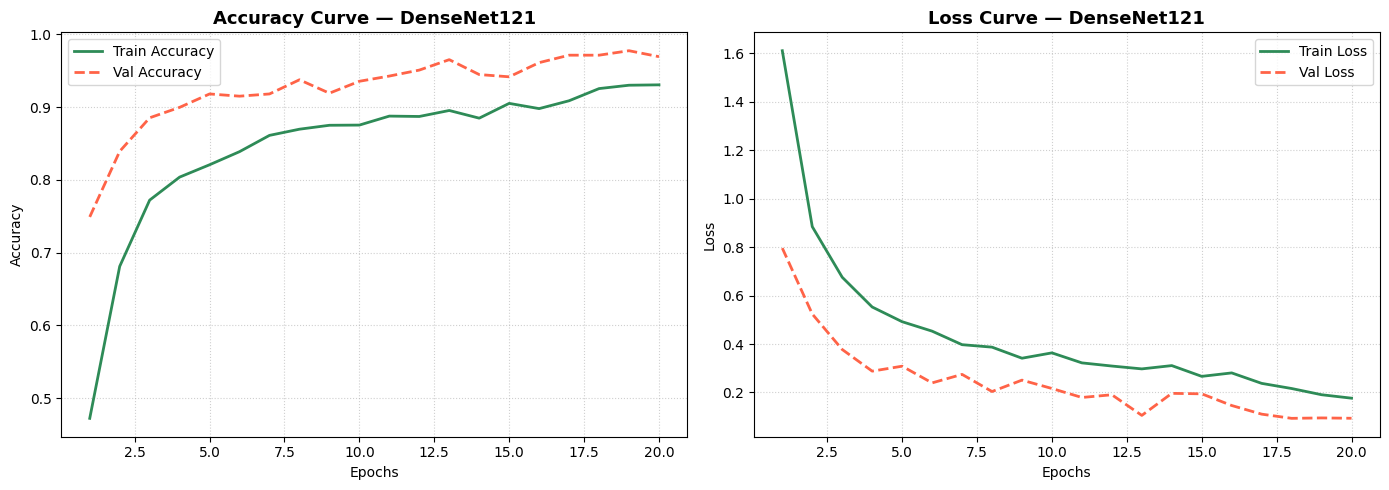

In [50]:
# TRAINING PERFORMANCE CURVES — DenseNet121

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
train_acc3 = history3.history['accuracy']
val_acc3 = history3.history['val_accuracy']
epochs3 = range(1, len(train_acc3) + 1)
plt.plot(epochs3, train_acc3, linewidth=2, label='Train Accuracy', color='seagreen')
plt.plot(epochs3, val_acc3, linewidth=2, label='Val Accuracy', color='tomato', linestyle='--')
plt.title("Accuracy Curve — DenseNet121", fontsize=13, fontweight='bold')
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()
plt.grid(linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
train_loss3 = history3.history['loss']
val_loss3 = history3.history['val_loss']
plt.plot(epochs3, train_loss3, linewidth=2, label='Train Loss', color='seagreen')
plt.plot(epochs3, val_loss3, linewidth=2, label='Val Loss', color='tomato', linestyle='--')
plt.title("Loss Curve — DenseNet121", fontsize=13, fontweight='bold')
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()
plt.grid(linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [51]:
# FINE-TUNING DenseNet121

print("~" * 65)
print("           STARTING FINE-TUNING — DenseNet121")
print("~" * 65)

# Unfreeze Base Model
base_model3.trainable = True

# Freeze Initial Layers (keep first 70% frozen)
total_layers3 = len(base_model3.layers)
freeze_until3 = int(total_layers3 * 0.70)

for layer in base_model3.layers[:freeze_until3]:
    layer.trainable = False

print(f"\\nTotal layers: {total_layers3}")
print(f"Layers frozen: {freeze_until3} | Layers unfrozen: {total_layers3 - freeze_until3}")

# Recompile with lower LR
model3.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled with lr=0.0001")

history_fine3 = model3.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_test, y_test_cat),
    epochs=40,
    callbacks=callbacks3,
    class_weight=class_weights,
    verbose=1
)

print("\\n" + "~" * 65)
print("           FINE-TUNING COMPLETED — DenseNet121")
print("~" * 65)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
           STARTING FINE-TUNING — DenseNet121
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
\nTotal layers: 427
Layers frozen: 298 | Layers unfrozen: 129
Model recompiled with lr=0.0001
Epoch 1/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 136s 568ms/step - accuracy: 0.8101 - loss: 0.5988 - val_accuracy: 0.9611 - val_loss: 0.1058 - learning_rate: 1.0000e-04
Epoch 2/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.9161 - loss: 0.2536 - val_accuracy: 0.9785 - val_loss: 0.0683 - learning_rate: 1.0000e-04
Epoch 3/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.9419 - loss: 0.1535 - val_accuracy: 0.9846 - val_loss: 0.0503 - learning_rate: 1.0000e-04
Epoch 4/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.9539 - loss: 0.1294 - val_accuracy: 0.9846 - val_loss: 0.0427 - learning_rate: 1.0000e-04
Epoch 5/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.9557 - loss: 0.1084 - val_

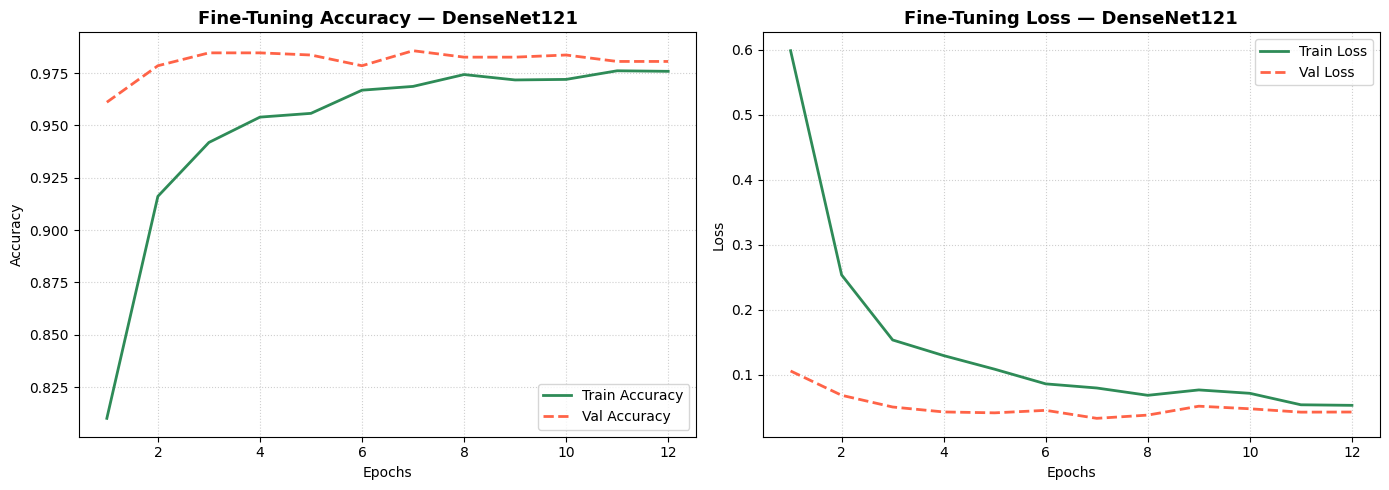

In [52]:
# FINE-TUNING PERFORMANCE CURVES — DenseNet121

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
fine_train_acc3 = history_fine3.history['accuracy']
fine_val_acc3   = history_fine3.history['val_accuracy']
fine_epochs3    = range(1, len(fine_train_acc3) + 1)
plt.plot(fine_epochs3, fine_train_acc3, linewidth=2, label='Train Accuracy', color='seagreen')
plt.plot(fine_epochs3, fine_val_acc3, linewidth=2, label='Val Accuracy', color='tomato', linestyle='--')
plt.title("Fine-Tuning Accuracy — DenseNet121", fontsize=13, fontweight='bold')
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()
plt.grid(linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
fine_train_loss3 = history_fine3.history['loss']
fine_val_loss3   = history_fine3.history['val_loss']
plt.plot(fine_epochs3, fine_train_loss3, linewidth=2, label='Train Loss', color='seagreen')
plt.plot(fine_epochs3, fine_val_loss3, linewidth=2, label='Val Loss', color='tomato', linestyle='--')
plt.title("Fine-Tuning Loss — DenseNet121", fontsize=13, fontweight='bold')
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()
plt.grid(linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [53]:
# PREDICTIONS & EVALUATION — DenseNet121

y_pred_probs3 = model3.predict(X_test)
y_pred3 = np.argmax(y_pred_probs3, axis=1)

accuracy3  = accuracy_score(y_test, y_pred3)
precision3 = precision_score(y_test, y_pred3, average='weighted')
recall3    = recall_score(y_test, y_pred3, average='weighted')
f1_score3  = f1_score(y_test, y_pred3, average='weighted')
logloss3   = log_loss(y_test, y_pred_probs3)

print("~" * 60)
print("        DenseNet121 MODEL PERFORMANCE")
print("~" * 60)
print(f"Accuracy   : {accuracy3:.4f}")
print(f"Precision  : {precision3:.4f}")
print(f"Recall     : {recall3:.4f}")
print(f"F1-Score   : {f1_score3:.4f}")
print(f"Log Loss   : {logloss3:.4f}")
print("~" * 60)

31/31 ━━━━━━━━━━━━━━━━━━━━ 26s 434ms/step
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        DenseNet121 MODEL PERFORMANCE
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Accuracy   : 0.9857
Precision  : 0.9871
Recall     : 0.9857
F1-Score   : 0.9858
Log Loss   : 0.0328
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [54]:
model3.save("DenseNet121_emotion_model.keras")
print("DenseNet121 model saved.")

DenseNet121 model saved.


In [55]:
# CLASSIFICATION REPORT — DenseNet121
print(classification_report(y_test, y_pred3, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

       Angry       1.00      1.00      1.00        97
     Anxiety       0.90      1.00      0.95       123
   Confusion       1.00      0.99      1.00       112
     Disgust       1.00      1.00      1.00        65
        Fear       1.00      0.94      0.97       198
       Happy       1.00      0.99      0.99        94
     Neutral       1.00      1.00      1.00       132
         Sad       1.00      1.00      1.00        80
     Suprise       1.00      1.00      1.00        75

    accuracy                           0.99       976
   macro avg       0.99      0.99      0.99       976
weighted avg       0.99      0.99      0.99       976



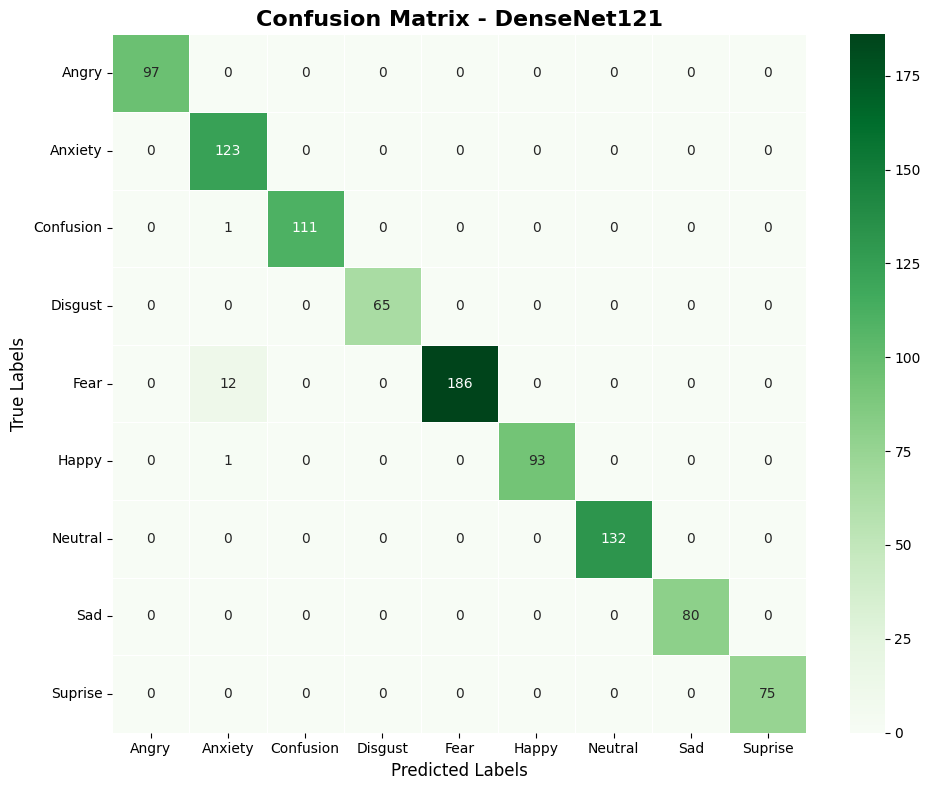

In [56]:
# CONFUSION MATRIX — DenseNet121

cm3 = confusion_matrix(y_test, y_pred3)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm3, annot=True, fmt='d', cmap='Greens',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, linecolor='white'
)
plt.title("Confusion Matrix - DenseNet121", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

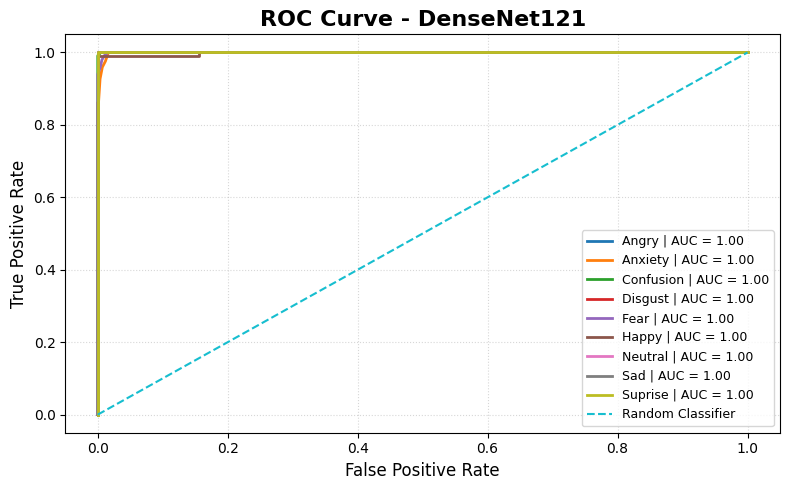

In [57]:
# ROC CURVE — DenseNet121

plt.figure(figsize=(8, 5))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs3[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{CLASS_NAMES[i]} | AUC = {roc_auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1.5, label='Random Classifier')
plt.title("ROC Curve - DenseNet121", fontsize=16, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.grid(linestyle=':', alpha=0.5)
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

In [58]:
# SOFT-VOTING ENSEMBLE — ResNet50 + DenseNet121

print("~" * 65)
print("       SOFT-VOTING ENSEMBLE MODEL")
print("~" * 65)

# Average probability outputs of both models
ensemble_probs = (y_pred_probs + y_pred_probs3) / 2.0

# Predicted class labels
y_pred_ensemble = np.argmax(ensemble_probs, axis=1)

# Metrics
acc_ens  = accuracy_score(y_test, y_pred_ensemble)
prec_ens = precision_score(
    y_test, y_pred_ensemble, average='weighted'
)
rec_ens  = recall_score(
    y_test, y_pred_ensemble, average='weighted'
)
f1_ens   = f1_score(
    y_test, y_pred_ensemble, average='weighted'
)
ll_ens   = log_loss(y_test, ensemble_probs)

print("~" * 65)
print("        ENSEMBLE MODEL PERFORMANCE")
print("~" * 65)

print(f"Accuracy   : {acc_ens:.4f}")
print(f"Precision  : {prec_ens:.4f}")
print(f"Recall     : {rec_ens:.4f}")
print(f"F1-Score   : {f1_ens:.4f}")
print(f"Log Loss   : {ll_ens:.4f}")

print("~" * 65)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
       SOFT-VOTING ENSEMBLE MODEL
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        ENSEMBLE MODEL PERFORMANCE
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Accuracy   : 0.9846
Precision  : 0.9850
Recall     : 0.9846
F1-Score   : 0.9847
Log Loss   : 0.0727
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [59]:
# CLASSIFICATION REPORT — Ensemble

print("~" * 65)
print("        CLASSIFICATION REPORT — ENSEMBLE")
print("~" * 65)

print(
    classification_report(
        y_test,
        y_pred_ensemble,
        target_names=CLASS_NAMES
    )
)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        CLASSIFICATION REPORT — ENSEMBLE
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
              precision    recall  f1-score   support

       Angry       0.99      1.00      0.99        97
     Anxiety       0.92      0.97      0.94       123
   Confusion       1.00      0.99      1.00       112
     Disgust       1.00      1.00      1.00        65
        Fear       0.98      0.95      0.97       198
       Happy       1.00      0.99      0.99        94
     Neutral       1.00      1.00      1.00       132
         Sad       1.00      1.00      1.00        80
     Suprise       1.00      1.00      1.00        75

    accuracy                           0.98       976
   macro avg       0.99      0.99      0.99       976
weighted avg       0.99      0.98      0.98       976



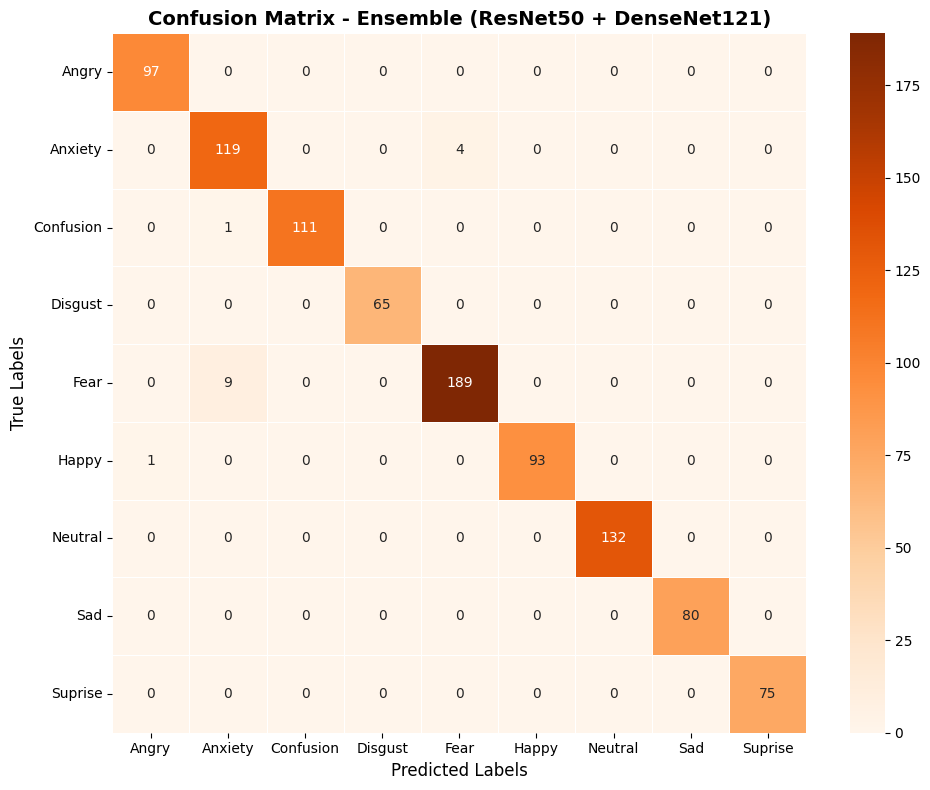

In [60]:
# CONFUSION MATRIX — Ensemble

cm_ens = confusion_matrix(
    y_test,
    y_pred_ensemble
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_ens,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    linecolor='white'
)

plt.title(
    "Confusion Matrix - Ensemble (ResNet50 + DenseNet121)",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

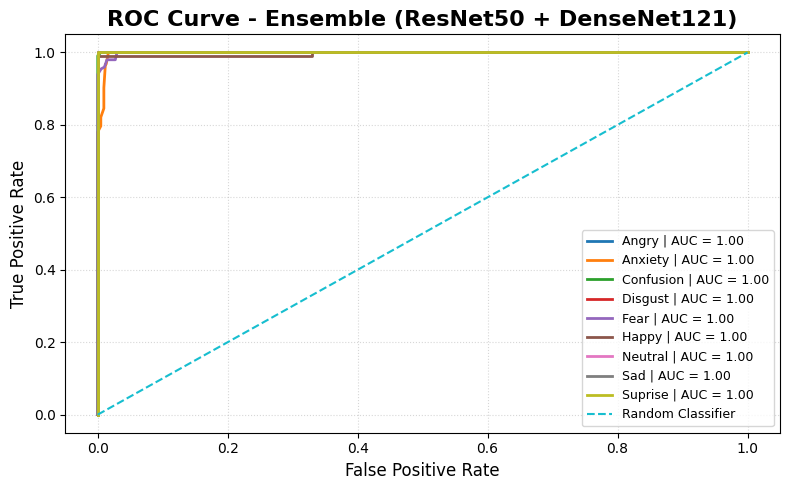

In [61]:
# ROC CURVE — ResNet50 + DenseNet121 Ensemble

plt.figure(figsize=(8, 5))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        ensemble_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{CLASS_NAMES[i]} | AUC = {roc_auc:.2f}"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.5,
    label='Random Classifier'
)

plt.title(
    "ROC Curve - Ensemble (ResNet50 + DenseNet121)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.grid(
    linestyle=':',
    alpha=0.5
)

plt.legend(
    fontsize=9,
    loc='lower right'
)

plt.tight_layout()
plt.show()

In [62]:
# Save ResNet50 + DenseNet121 Ensemble for Web App

import os
import json
import numpy as np

print("Saving Ensemble Models for Web App")
print()


# Create model directory

MODEL_DIR = "/kaggle/working/ensemble_models"

os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Model directory: {MODEL_DIR}")
print()


# Save ResNet50 model

resnet_path = os.path.join(
    MODEL_DIR,
    "resnet50_finetuned.keras"
)

model1.save(resnet_path)

print("ResNet50 model saved:")
print(resnet_path)
print()


# Save DenseNet121 model

densenet_path = os.path.join(
    MODEL_DIR,
    "densenet121_finetuned.keras"
)

model2.save(densenet_path)

print("DenseNet121 model saved:")
print(densenet_path)
print()


# Save class names

class_names_path = os.path.join(
    MODEL_DIR,
    "class_names.json"
)

class_names = [str(name) for name in CLASS_NAMES]

with open(class_names_path, "w") as f:
    json.dump(class_names, f, indent=4)

print("Class names saved:")
print(class_names_path)
print()

print("Class order:")

for i, name in enumerate(class_names):
    print(f"{i}: {name}")

print()


# Save ensemble configuration

IMAGE_SIZE = 224

ensemble_config = {
    "models": [
        "resnet50_finetuned.keras",
        "densenet121_finetuned.keras"
    ],
    "ensemble_type": "soft_voting",
    "weights": [0.5, 0.5],
    "image_size": [IMAGE_SIZE, IMAGE_SIZE],
    "num_classes": int(NUM_CLASSES),
    "class_names_file": "class_names.json"
}

config_path = os.path.join(
    MODEL_DIR,
    "ensemble_config.json"
)

with open(config_path, "w") as f:
    json.dump(ensemble_config, f, indent=4)

print("Ensemble configuration saved:")
print(config_path)
print()


# Save model information

summary_path = os.path.join(
    MODEL_DIR,
    "model_info.txt"
)

with open(summary_path, "w") as f:

    f.write("ResNet50 + DenseNet121 Soft Voting Ensemble\n")
    f.write("\n")

    f.write("Models:\n")
    f.write("1. ResNet50\n")
    f.write("2. DenseNet121\n")
    f.write("\n")

    f.write("Ensemble Method:\n")
    f.write("Soft Voting / Probability Averaging\n")
    f.write("\n")

    f.write("Model Weights:\n")
    f.write("ResNet50: 0.5\n")
    f.write("DenseNet121: 0.5\n")
    f.write("\n")

    f.write(f"Image Size: {IMAGE_SIZE} x {IMAGE_SIZE}\n")
    f.write(f"Number of Classes: {NUM_CLASSES}\n")
    f.write("\n")

    f.write("Class Names:\n")

    for i, name in enumerate(class_names):
        f.write(f"{i}: {name}\n")

print("Model information saved:")
print(summary_path)
print()


# Verify saved files

print("Saved Files")

for file_name in os.listdir(MODEL_DIR):

    file_path = os.path.join(
        MODEL_DIR,
        file_name
    )

    size_mb = os.path.getsize(file_path) / (1024 * 1024)

    print(f"{file_name:<35} {size_mb:.2f} MB")

print()
print("Ensemble saving completed successfully")

Saving Ensemble Models for Web App

Model directory: /kaggle/working/ensemble_models

ResNet50 model saved:
/kaggle/working/ensemble_models/resnet50_finetuned.keras

DenseNet121 model saved:
/kaggle/working/ensemble_models/densenet121_finetuned.keras

Class names saved:
/kaggle/working/ensemble_models/class_names.json

Class order:
0: Angry
1: Anxiety
2: Confusion
3: Disgust
4: Fear
5: Happy
6: Neutral
7: Sad
8: Suprise

Ensemble configuration saved:
/kaggle/working/ensemble_models/ensemble_config.json

Model information saved:
/kaggle/working/ensemble_models/model_info.txt

Saved Files
resnet50_finetuned.keras            206.91 MB
densenet121_finetuned.keras         87.94 MB
model_info.txt                      0.00 MB
ensemble_config.json                0.00 MB
class_names.json                    0.00 MB

Ensemble saving completed successfully


In [63]:
import shutil

zip_path = shutil.make_archive(
    "/kaggle/working/ensemble_models_webapp",
    "zip",
    MODEL_DIR
)

print()
print("ZIP file created:")
print(zip_path)


ZIP file created:
/kaggle/working/ensemble_models_webapp.zip
